In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel('/content/Delinquency_prediction_dataset.xlsx')

In [3]:
df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

In [5]:
df.describe()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
count,500.000000,461.000000,498.000000,500.000000,500.000000,500.000000,471.000000,500.000000,500.000000
mean,46.266000,108379.893709,577.716867,0.491446,2.968000,0.160000,48654.428875,0.298862,9.740000
std,16.187629,53662.723741,168.881211,0.197103,1.946935,0.366973,29395.537273,0.094521,5.923054
min,18.000000,15404.000000,301.000000,0.050000,0.000000,0.000000,612.000000,0.100000,0.000000
25%,33.000000,62295.000000,418.250000,0.356486,1.000000,0.000000,23716.500000,0.233639,5.000000
50%,46.500000,107658.000000,586.000000,0.485636,3.000000,0.000000,45776.000000,0.301634,10.000000
75%,59.250000,155734.000000,727.250000,0.634440,5.000000,0.000000,75546.500000,0.362737,15.000000
max,74.000000,199943.000000,847.000000,1.025843,6.000000,1.000000,99620.000000,0.552956,19.000000


In [6]:
!pip install ydata-profiling

In [7]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df)

/tmp/ipykernel_29237/2235379448.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [8]:
profile.to_file("data_analysis_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 19/19 [00:00<00:00, 29.67it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
df['Missed_Payments'].unique()

array([3, 6, 0, 2, 5, 4, 1])

In [10]:
df[((df['Missed_Payments'] == 5) | (df['Missed_Payments'] == 6)) & (df['Credit_Score']< 700)]

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
7,CUST0008,56,123215.0,415.0,0.532715,5,0,55776.0,0.358695,EMP,1,Student,New York,On-time,On-time,On-time,Late,Missed,Late
8,CUST0009,36,66991.0,405.0,0.413035,5,1,NaN,0.219854,Employed,12,Student,Phoenix,On-time,On-time,On-time,Missed,Late,On-time
13,CUST0014,70,117023.0,528.0,0.105173,5,0,95136.0,0.469018,retired,10,Standard,Los Angeles,On-time,Missed,Missed,Missed,On-time,On-time
25,CUST0026,19,193998.0,515.0,0.255552,5,0,NaN,0.259893,EMP,12,Gold,Phoenix,Late,Missed,On-time,Late,Missed,On-time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484,CUST0485,40,116570.0,556.0,0.424134,5,0,76567.0,0.201378,Employed,14,Standard,Houston,Missed,On-time,Late,Missed,On-time,On-time
485,CUST0486,39,39285.0,567.0,0.272266,6,0,37463.0,0.441856,EMP,14,Standard,Chicago,Missed,Missed,On-time,Late,Missed,Late
486,CUST0487,68,43732.0,524.0,0.237267,6,0,53553.0,0.384283,retired,4,Business,Houston,On-time,Late,On-time,On-time,On-time,On-time
489,CUST0490,39,153877.0,618.0,0.439277,5,0,36029.0,0.200723,Employed,13,Business,Los Angeles,On-time,Missed,On-time,On-time,Late,On-time


In [11]:
#Identify the top 3 variables most likely to predict delinquency based on this dataset. Provide brief reasoning.
dataset = df[((df['Missed_Payments'] == 5) | (df['Missed_Payments'] == 6)) & (df['Credit_Score']< 400) & (df['Delinquent_Account'] == 1)]

dataset.head(3)

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
34,CUST0035,59,69693.0,316.0,0.280943,5,1,60278.0,0.100000,retired,4,Platinum,Houston,On-time,Missed,Late,Late,On-time,Late
170,CUST0171,66,38959.0,310.0,0.617640,5,1,67460.0,0.139732,Self-employed,19,Business,Phoenix,Missed,Late,Late,Missed,Late,On-time
356,CUST0357,35,32955.0,359.0,0.448320,5,1,77348.0,0.468567,Self-employed,13,Gold,Chicago,Missed,On-time,Missed,On-time,Late,Missed


In [12]:
numerical_cols = df.select_dtypes(include=np.number).columns

numerical_cols

Index(['Age', 'Income', 'Credit_Score', 'Credit_Utilization',
       'Missed_Payments', 'Delinquent_Account', 'Loan_Balance',
       'Debt_to_Income_Ratio', 'Account_Tenure'],
      dtype='object')

In [13]:
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_with_delinquency = df[numerical_cols].corr()['Delinquent_Account'].sort_values(ascending=False)
display(correlation_with_delinquency)

,Delinquent_Account
Delinquent_Account,1.000000
Income,0.045409
Credit_Score,0.034833
Debt_to_Income_Ratio,0.034386
Credit_Utilization,0.034224
Age,0.022508
Loan_Balance,-0.004320
Missed_Payments,-0.026478
Account_Tenure,-0.039829


In [14]:
print('Delinquency Rate by Employment Status:')
display(df.groupby('Employment_Status')['Delinquent_Account'].mean().sort_values(ascending=False))

print('\nDelinquency Rate by Credit Card Type:')
display(df.groupby('Credit_Card_Type')['Delinquent_Account'].mean().sort_values(ascending=False))

Delinquency Rate by Employment Status:


,Delinquent_Account
Employment_Status,
Unemployed,0.193548
Employed,0.182927
Self-employed,0.162500
employed,0.155844
EMP,0.148148
retired,0.114943



Delinquency Rate by Credit Card Type:


,Delinquent_Account
Credit_Card_Type,
Business,0.212963
Student,0.178571
Gold,0.144068
Standard,0.127907
Platinum,0.118421


Now, let's explore the detailed payment history (`Month_1` to `Month_6`). We can count the occurrences of 'Missed' and 'Late' payments and see their relationship with the `Delinquent_Account`.

In [15]:
payment_cols = ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']

# Count 'Missed' and 'Late' payments per row
df['num_missed_or_late'] = df[payment_cols].apply(lambda x: x.str.contains('Missed|Late').sum(), axis=1)

print('Delinquency Rate by Number of Missed or Late Payments (from Month_1 to Month_6):')
display(df.groupby('num_missed_or_late')['Delinquent_Account'].mean().sort_values(ascending=False))

Delinquency Rate by Number of Missed or Late Payments (from Month_1 to Month_6):


,Delinquent_Account
num_missed_or_late,
2,0.205128
4,0.179012
6,0.173913
3,0.168142
5,0.120301
1,0.000000


In [17]:
df.sample(5)

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,num_missed_or_late
293,CUST0294,24,NaN,436.0,0.432228,2,0,45595.0,0.153166,employed,19,Business,New York,Late,Late,On-time,Missed,On-time,Missed,4
39,CUST0040,68,97750.0,352.0,0.394268,6,0,91432.0,0.212301,EMP,1,Gold,Phoenix,On-time,Late,Late,On-time,On-time,On-time,2
342,CUST0343,66,18267.0,541.0,0.732044,6,0,NaN,0.199240,employed,11,Business,Los Angeles,Late,On-time,Missed,Late,Missed,On-time,4
315,CUST0316,65,32019.0,419.0,0.311317,4,0,13355.0,0.327359,Unemployed,19,Platinum,Los Angeles,Late,On-time,Late,On-time,On-time,On-time,2
53,CUST0054,42,194819.0,339.0,0.657863,3,0,29427.0,0.133472,employed,4,Standard,Houston,Late,Missed,On-time,On-time,On-time,Missed,3


In [46]:
dataset = df[(df['Credit_Score']< 400) & (df['Delinquent_Account'] == 1)]

dataset.sort_values(by='num_missed_or_late', ascending=False).head(3)

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,num_missed_or_late
311,CUST0312,52,176426.0,320.0,0.392013,3,1,31674.0,0.277503,Employed,6,Business,Chicago,Missed,Late,Missed,Missed,Late,Missed,6
362,CUST0363,53,107193.0,316.0,0.332450,1,1,86447.0,0.331377,Self-employed,6,Standard,Chicago,Missed,Missed,Missed,Missed,Late,Missed,6
170,CUST0171,66,38959.0,310.0,0.617640,5,1,67460.0,0.139732,Self-employed,19,Business,Phoenix,Missed,Late,Late,Missed,Late,On-time,5


### Drop rows where Credit Score is null because there are only 2 rows and showing inadequate data(Eg. age is 18 and employment status is retired)

In [37]:
#drop columns where creditscore is null
df.dropna(subset=['Credit_Score'], inplace=True)

In [40]:
df.shape

(498, 20)

## Replace null income with 0 because it doenot affect our data as no income is 0 income.

In [42]:
#replace income column nul values with 0
df['Income'].replace(np.nan, 0, inplace=True)

/tmp/ipykernel_29237/2291295094.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].replace(np.nan, 0, inplace=True)


Replace null Loan_Balance with 0 means no Loan_Balance

In [44]:
df['Loan_Balance'].replace(np.nan, 0, inplace=True)

/tmp/ipykernel_29237/2494044671.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Loan_Balance'].replace(np.nan, 0, inplace=True)


In [47]:
# Calculate mean and standard deviation of non-zero income values
non_zero_income = df[df['Income'] != 0]['Income']
income_mean = non_zero_income.mean()
income_std = non_zero_income.std()

# Identify the number of rows where Income is 0
num_zero_income = df[df['Income'] == 0].shape[0]

print(f"Mean of non-zero income: {income_mean:.2f}")
print(f"Standard deviation of non-zero income: {income_std:.2f}")
print(f"Number of zero income values to impute: {num_zero_income}")

Mean of non-zero income: 108350.54
Standard deviation of non-zero income: 53717.44
Number of zero income values to impute: 38


In [48]:
# Generate synthetic income values from a normal distribution
synthetic_income_values = np.random.normal(loc=income_mean, scale=income_std, size=num_zero_income)

# Ensure generated values are non-negative; replace any negative values with a small positive value if needed
synthetic_income_values[synthetic_income_values < 0] = non_zero_income.min() # Use the minimum non-zero income as a floor

# Replace the 0 income values with the synthetic ones
df.loc[df['Income'] == 0, 'Income'] = synthetic_income_values

print("Synthetic income values generated and imputed.")

Synthetic income values generated and imputed.


In [49]:
# Display info and describe for the Income column to verify imputation
df['Income'].info()
display(df['Income'].describe())

<class 'pandas.core.series.Series'>
Index: 498 entries, 0 to 499
Series name: Income
Non-Null Count  Dtype  
--------------  -----  
498 non-null    float64
dtypes: float64(1)
memory usage: 7.8 KB


,Income
count,498.000000
mean,108003.811577
std,53764.655507
min,15404.000000
25%,62951.750000
50%,106137.000000
75%,154487.000000
max,250083.724159


## Detect patterns and risk factors

### 1. Distributions of Key Numerical Features vs. Delinquency

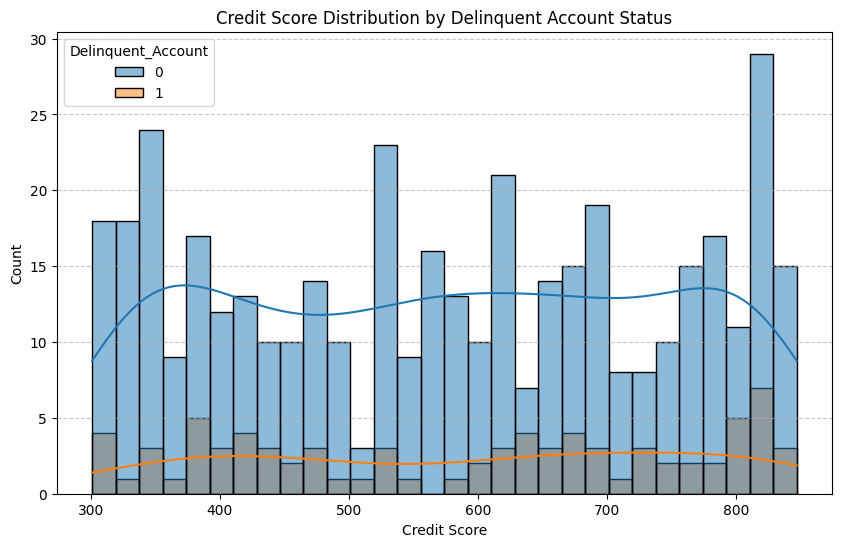

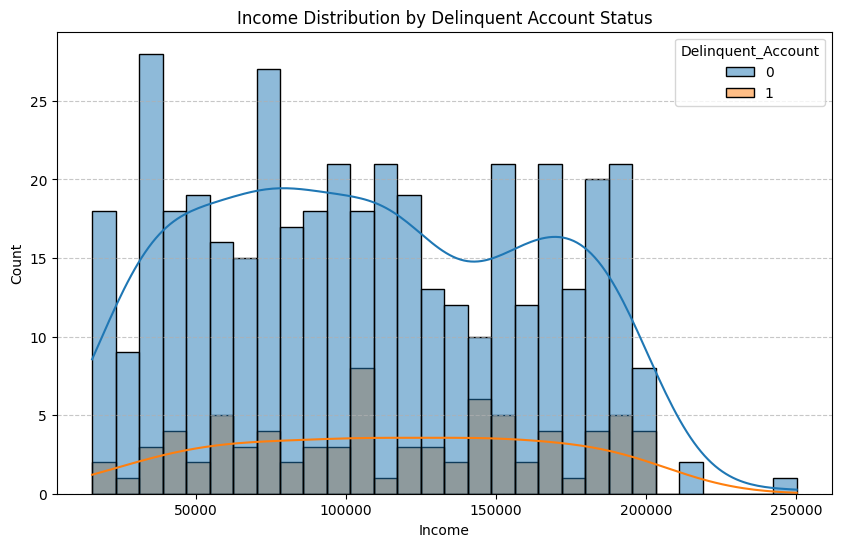

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Credit_Score distribution by Delinquent_Account
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Credit_Score', hue='Delinquent_Account', kde=True, bins=30)
plt.title('Credit Score Distribution by Delinquent Account Status')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualize Income distribution by Delinquent_Account
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Income', hue='Delinquent_Account', kde=True, bins=30)
plt.title('Income Distribution by Delinquent Account Status')
plt.xlabel('Income')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2. Delinquency Rates by Categorical Features

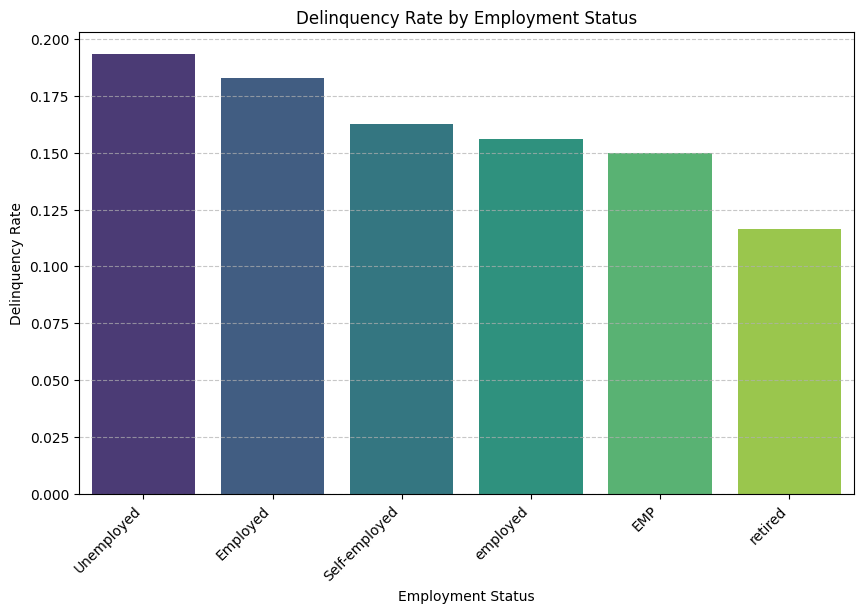

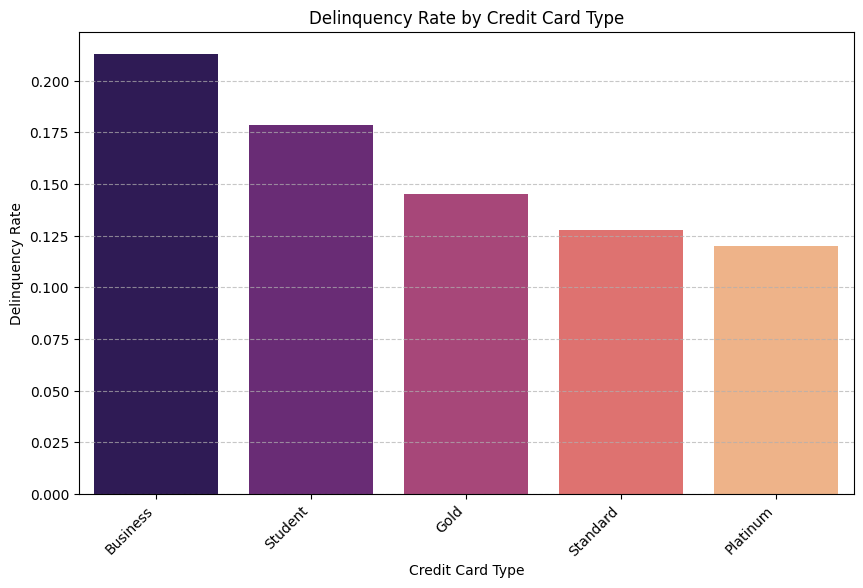

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate delinquency rates for Employment Status
employment_delinquency = df.groupby('Employment_Status')['Delinquent_Account'].mean().sort_values(ascending=False).reset_index()

# Delinquency Rate by Employment Status
plt.figure(figsize=(10, 6))
sns.barplot(x='Employment_Status', y='Delinquent_Account', data=employment_delinquency, palette='viridis', hue='Employment_Status', legend=False)
plt.title('Delinquency Rate by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Delinquency Rate')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate delinquency rates for Credit Card Type
credit_card_delinquency = df.groupby('Credit_Card_Type')['Delinquent_Account'].mean().sort_values(ascending=False).reset_index()

# Delinquency Rate by Credit Card Type
plt.figure(figsize=(10, 6))
sns.barplot(x='Credit_Card_Type', y='Delinquent_Account', data=credit_card_delinquency, palette='magma', hue='Credit_Card_Type', legend=False)
plt.title('Delinquency Rate by Credit Card Type')
plt.xlabel('Credit Card Type')
plt.ylabel('Delinquency Rate')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3. Impact of Monthly Payment History (`Month_X` columns)

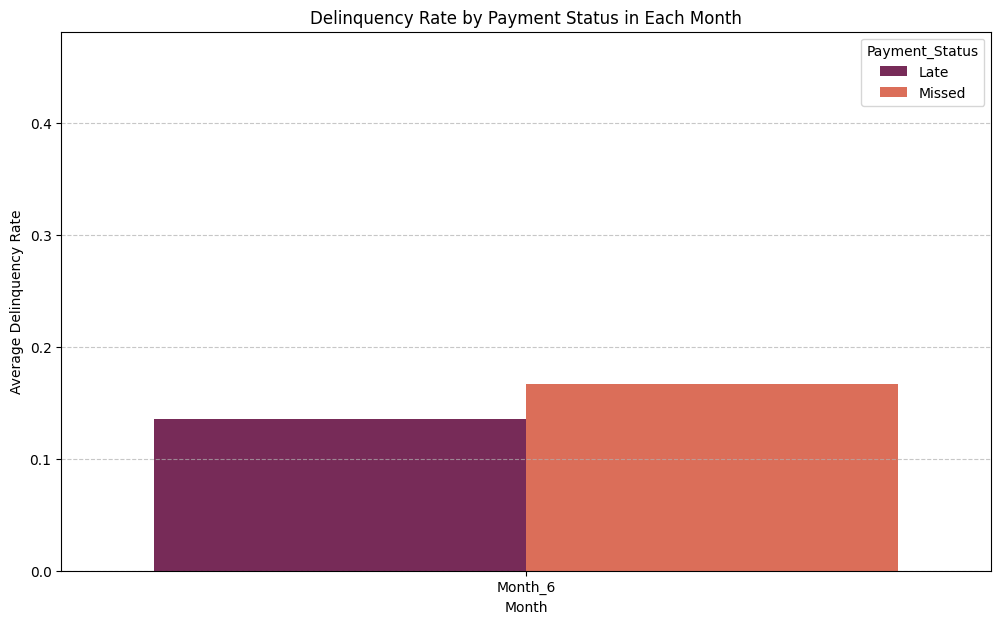

In [52]:
# Calculate the percentage of 'Missed' or 'Late' payments per month, grouped by Delinquent_Account
payment_cols = ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']

monthly_risk_factors = []
for month_col in payment_cols:
    temp_df = df.groupby(month_col)['Delinquent_Account'].agg(['mean', 'count']).reset_index()
    temp_df['month'] = month_col
    monthly_risk_factors.append(temp_df)

monthly_risk_factors_df = pd.concat(monthly_risk_factors)
monthly_risk_factors_df.rename(columns={'mean': 'Delinquency_Rate', month_col: 'Payment_Status'}, inplace=True)

# Filter for 'Missed' and 'Late' payment statuses to highlight risk factors
risk_status_df = monthly_risk_factors_df[monthly_risk_factors_df['Payment_Status'].isin(['Missed', 'Late'])]

plt.figure(figsize=(12, 7))
sns.barplot(data=risk_status_df, x='month', y='Delinquency_Rate', hue='Payment_Status', palette='rocket')
plt.title('Delinquency Rate by Payment Status in Each Month')
plt.xlabel('Month')
plt.ylabel('Average Delinquency Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, df['Delinquent_Account'].mean() * 3) # Set y-limit for better visualization if rates are low
plt.show()

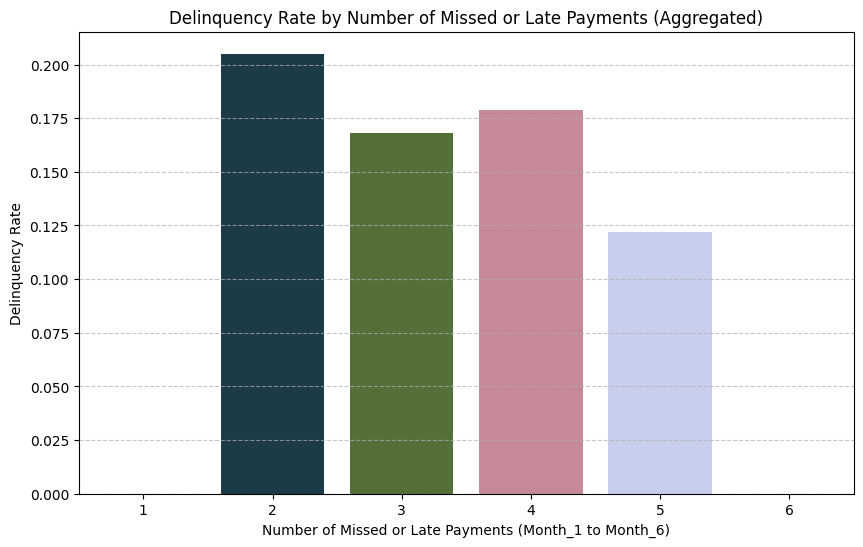

In [55]:
# Analyze the derived feature 'num_missed_or_late'
# Calculate delinquency rates for num_missed_or_late
num_missed_late_delinquency = df.groupby('num_missed_or_late')['Delinquent_Account'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='num_missed_or_late', y='Delinquent_Account', data=num_missed_late_delinquency,
            palette='cubehelix', hue='num_missed_or_late', legend=False)
plt.title('Delinquency Rate by Number of Missed or Late Payments (Aggregated)')
plt.xlabel('Number of Missed or Late Payments (Month_1 to Month_6)')
plt.ylabel('Delinquency Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Numerical Summary: Delinquency Rate by Number of Missed or Late Payments

This table presents the average delinquency rate for each count of missed or late payments (from `Month_1` to `Month_6`), which was visualized in the previous bar plot.

In [57]:
# Display the DataFrame containing delinquency rates by num_missed_or_late
display(num_missed_late_delinquency)

,num_missed_or_late,Delinquent_Account
0,1,0.000000
1,2,0.205128
2,3,0.168142
3,4,0.179012
4,5,0.122137
5,6,0.173913
